<a href="https://colab.research.google.com/github/venkatasai-eng/MLA0305-REINFORCEMENT-LEARNING-/blob/main/EXP_NO_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

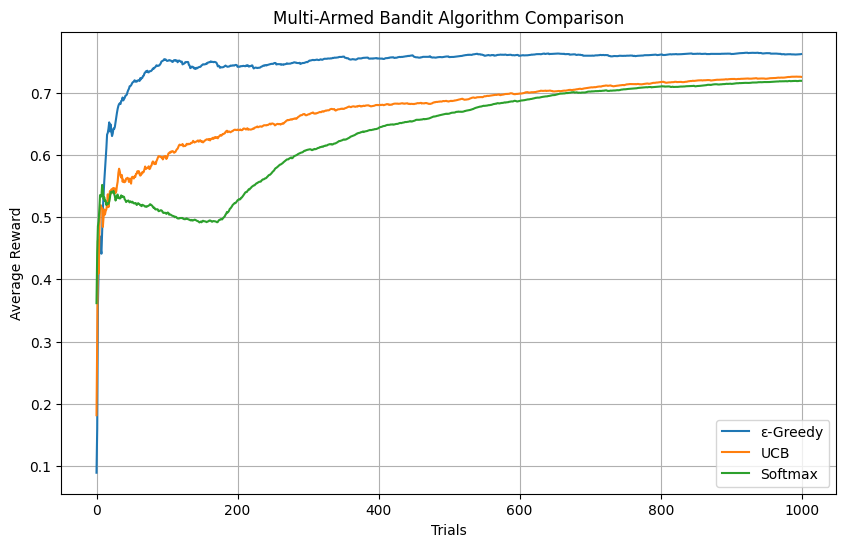

Best Arm: 2
ε-Greedy Final Average Reward: 0.763
UCB Final Average Reward: 0.726
Softmax Final Average Reward: 0.72


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_arms = 5
n_trials = 1000

true_rewards = [0.2, 0.5, 0.8, 0.4, 0.6]

def epsilon_greedy(epsilon=0.1):
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = []

    for t in range(n_trials):
        if np.random.rand() < epsilon:
            action = np.random.randint(n_arms)
        else:
            action = np.argmax(Q)

        reward = np.random.normal(true_rewards[action], 0.1)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
        rewards.append(reward)

    return rewards

def ucb():
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = []

    for t in range(n_trials):
        if t < n_arms:
            action = t
        else:
            ucb_values = Q + np.sqrt(2 * np.log(t + 1) / N)
            action = np.argmax(ucb_values)

        reward = np.random.normal(true_rewards[action], 0.1)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
        rewards.append(reward)

    return rewards


def softmax(temperature=0.1):
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = []

    for t in range(n_trials):

        probabilities = np.exp(Q / temperature)
        probabilities /= np.sum(probabilities)

        action = np.random.choice(n_arms, p=probabilities)

        reward = np.random.normal(true_rewards[action], 0.1)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
        rewards.append(reward)

    return rewards


epsilon_rewards = epsilon_greedy(0.1)
ucb_rewards = ucb()
softmax_rewards = softmax(0.1)

epsilon_avg = np.cumsum(epsilon_rewards) / np.arange(1, n_trials + 1)
ucb_avg = np.cumsum(ucb_rewards) / np.arange(1, n_trials + 1)
softmax_avg = np.cumsum(softmax_rewards) / np.arange(1, n_trials + 1)

plt.figure(figsize=(10, 6))

plt.plot(epsilon_avg, label="ε-Greedy")
plt.plot(ucb_avg, label="UCB")
plt.plot(softmax_avg, label="Softmax")

plt.xlabel("Trials")
plt.ylabel("Average Reward")
plt.title("Multi-Armed Bandit Algorithm Comparison")
plt.legend()
plt.grid()

plt.show()

print("Best Arm:", np.argmax(true_rewards))
print("ε-Greedy Final Average Reward:", round(epsilon_avg[-1], 3))
print("UCB Final Average Reward:", round(ucb_avg[-1], 3))
print("Softmax Final Average Reward:", round(softmax_avg[-1], 3))